<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/9_Data_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Dataset and Basic Data Exploration**

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("adult_with_headers (1).csv")
print("Dataset Shape:",df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe(include="all"))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:",df.duplicated().sum())

Dataset Shape: (32561, 15)

First 5 Rows:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174           

**Handle Missing Values**

In [12]:

df=df.replace(" ?",np.nan)
print("Missing Values Before Handling:")
print(df.isnull().sum())
categorical_cols=df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
numeric_cols=df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())
print("\nMissing Values After Handling:")
print(df.isnull().sum())

Missing Values Before Handling:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Missing Values After Handling:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


**Explore Categorical Variables and Select Encoding Techniques**

In [13]:

categorical_cols=df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(col,":",df[col].nunique(),"categories")
one_hot_cols=[col for col in categorical_cols if col!="income" and df[col].nunique()<5]
label_cols=[col for col in categorical_cols if col!="income" and df[col].nunique()>=5]
print("\nOne-Hot Encoding Columns:",one_hot_cols)
print("Label Encoding Columns:",label_cols)

workclass : 8 categories
education : 16 categories
marital_status : 7 categories
occupation : 14 categories
relationship : 6 categories
race : 5 categories
sex : 2 categories
native_country : 41 categories
income : 2 categories

One-Hot Encoding Columns: ['sex']
Label Encoding Columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


**One-Hot Encoding and Label Encoding**

In [14]:

from sklearn.preprocessing import LabelEncoder
df_encoded=df.copy()
label_encoders={}
for col in label_cols:
    encoder=LabelEncoder()
    df_encoded[col]=encoder.fit_transform(df_encoded[col])
    label_encoders[col]=encoder
df_encoded=pd.get_dummies(df_encoded,columns=one_hot_cols,dtype=int)
income_encoder=LabelEncoder()
df_encoded["income"]=income_encoder.fit_transform(df_encoded["income"])
print("Encoded Dataset:")
print(df_encoded.head())
print("\nEncoded Dataset Shape:",df_encoded.shape)

Encoded Dataset:
   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          9             13               4   
1   50          5   83311          9             13               2   
2   38          3  215646         11              9               0   
3   53          3  234721          1              7               2   
4   28          3  338409          9             13               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           0             1     4          2174             0              40   
1           3             0     4             0             0              13   
2           5             1     4             0             0              40   
3           5             0     2             0             0              40   
4           9             5     2             0             0              40   

   native_country  income  sex_ Female  sex_ Male  
0              38

**Feature Engineering**

In [15]:

df_encoded["capital_net"]=df_encoded["capital_gain"]-df_encoded["capital_loss"]
df_encoded["hours_per_age"]=df_encoded["hours_per_week"]/(df_encoded["age"]+1)
print("New Features Created:")
print("1. capital_net = capital_gain - capital_loss")
print("2. hours_per_age = hours_per_week / (age + 1)")
print(df_encoded[["capital_net","hours_per_age"]].head())
print("\nRationale: capital_net represents the net capital amount, while hours_per_age represents work hours relative to age.")

New Features Created:
1. capital_net = capital_gain - capital_loss
2. hours_per_age = hours_per_week / (age + 1)
   capital_net  hours_per_age
0         2174       1.000000
1            0       0.254902
2            0       1.025641
3            0       0.740741
4            0       1.379310

Rationale: capital_net represents the net capital amount, while hours_per_age represents work hours relative to age.


**Log Transformation**

Original Capital Gain Skewness: 11.953847687699799
Transformed Capital Gain Skewness: 3.096143524467517


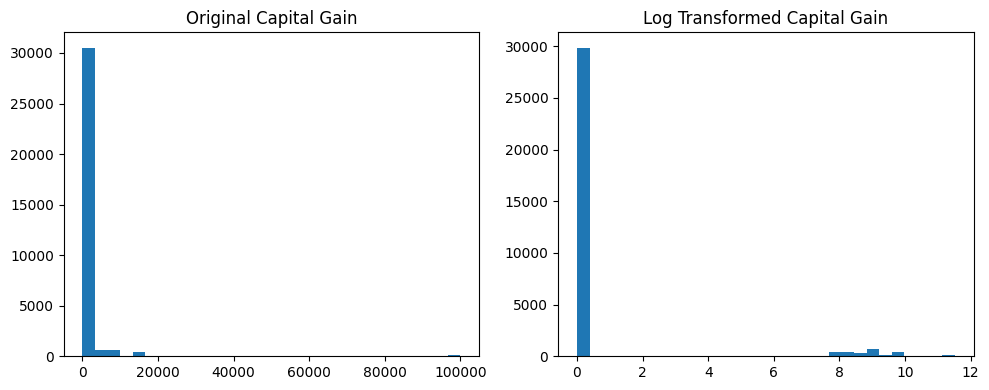

Log transformation is applied because capital_gain is highly right-skewed and log1p reduces the effect of extreme values.


In [16]:

df_encoded["capital_gain_log"]=np.log1p(df_encoded["capital_gain"])
print("Original Capital Gain Skewness:",df_encoded["capital_gain"].skew())
print("Transformed Capital Gain Skewness:",df_encoded["capital_gain_log"].skew())
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_encoded["capital_gain"],bins=30)
plt.title("Original Capital Gain")
plt.subplot(1,2,2)
plt.hist(df_encoded["capital_gain_log"],bins=30)
plt.title("Log Transformed Capital Gain")
plt.tight_layout()
plt.show()
print("Log transformation is applied because capital_gain is highly right-skewed and log1p reduces the effect of extreme values.")

**Standard Scaling and Min-Max Scaling**

In [17]:

from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaling_cols=["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week","capital_net","hours_per_age","capital_gain_log"]
standard_scaler=StandardScaler()
minmax_scaler=MinMaxScaler()
standard_scaled=standard_scaler.fit_transform(df_encoded[scaling_cols])
minmax_scaled=minmax_scaler.fit_transform(df_encoded[scaling_cols])
standard_df=pd.DataFrame(standard_scaled,columns=scaling_cols)
minmax_df=pd.DataFrame(minmax_scaled,columns=scaling_cols)
print("Standard Scaled Data:")
print(standard_df.head())
print("\nMin-Max Scaled Data:")
print(minmax_df.head())
print("\nStandard Scaling: Preferred when features have different scales and approximately normal distributions or when algorithms depend on mean and standard deviation.")
print("Min-Max Scaling: Preferred when features need to be converted to a fixed range such as 0 to 1.")

Standard Scaled Data:
        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  capital_net  hours_per_age  capital_gain_log  
0       -0.035429     0.159762      -0.276052          2.831370  
1       -2.222153    -0.133670      -1.879102         -0.299271  
2       -0.035429    -0.133670      -0.220886         -0.299271  
3       -0.035429    -0.133670      -0.833838         -0.299271  
4       -0.035429    -0.133670       0.540021         -0.299271  

Min-Max Scaled Data:
        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.

**Isolation Forest**

In [18]:

from sklearn.ensemble import IsolationForest
isolation_data=df_encoded[scaling_cols]
isolation_model=IsolationForest(contamination=0.05,random_state=42)
outlier_prediction=isolation_model.fit_predict(isolation_data)
df_encoded["outlier"]=outlier_prediction
print("Normal Records:",(df_encoded["outlier"]==1).sum())
print("Outlier Records:",(df_encoded["outlier"]==-1).sum())
print("\nOutlier Percentage:",round((df_encoded["outlier"]==-1).mean()*100,2),"%")

Normal Records: 30933
Outlier Records: 1628

Outlier Percentage: 5.0 %


**Predictive Power Score Analysis**

In [19]:

!pip install -q ppscore
import ppscore as pps
pps_matrix=pps.matrix(df_encoded)
pps_results=pps_matrix.sort_values("ppscore",ascending=False)
print("Top Predictive Power Score Relationships:")
print(pps_results[["x","y","ppscore"]].head(20))

Top Predictive Power Score Relationships:
                  x               y  ppscore
399         outlier         outlier      1.0
21        workclass       workclass      1.0
357   hours_per_age   hours_per_age      1.0
336     capital_net     capital_net      1.0
314       sex_ Male     sex_ Female      1.0
315       sex_ Male       sex_ Male      1.0
295     sex_ Female       sex_ Male      1.0
294     sex_ Female     sex_ Female      1.0
273          income          income      1.0
252  native_country  native_country      1.0
64        education   education_num      1.0
231  hours_per_week  hours_per_week      1.0
210    capital_loss    capital_loss      1.0
189    capital_gain    capital_gain      1.0
147    relationship    relationship      1.0
168            race            race      1.0
42           fnlwgt          fnlwgt      1.0
126      occupation      occupation      1.0
0               age             age      1.0
105  marital_status  marital_status      1.0


##**One-Hot Encoding:**
**Advantages:** Does not impose an artificial order on categories and works well for nominal categorical variables.

**Disadvantages:** Can create many columns when a categorical variable has many categories.
##**Label Encoding:**
**Advantages:** Converts categories into numerical values and uses fewer columns.

**Disadvantages:** The numerical values can imply an artificial order between categories.